In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
def format_label(folder):
    """Formats the display name of the folders to get the correct experiment names

    Args:
        folder (str): Folder name

    Returns:
        str: Formatted display name for the current experiment
    """
    if folder.startswith("yolofn_confidence"):
        conf = folder.split("confidence")[1]
        return f"Yolo BBox, Conf {conf}"
    elif folder == "baseline":
        return "Multi-label on full-image"
    elif folder == "gt":
        return "Multi-class on GT BBox"
    else:
        return folder

def read_class_f1(folder, path):
    """Returns the F1-Scores per class for a given folder

    Args:
        folder (str): Name of the folder of the experiment of which the F1-Score per class should be determined

    Returns:
        dict: The F1-Scores for each class
    """
    f1_scores = {}
    metrics_file = os.path.join(path, folder, "metrics_results.txt")
    with open(metrics_file, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f.readlines()]
        for i, line in enumerate(lines):
            if line.startswith("Klasse:"):
                cls = line.split(":")[1].strip()
                f1_line = lines[i+2]
                if "F1 Score" in f1_line or "F1-Score" in f1_line:
                    value = float(f1_line.split(":")[1].strip())
                    f1_scores[cls] = value
    return f1_scores

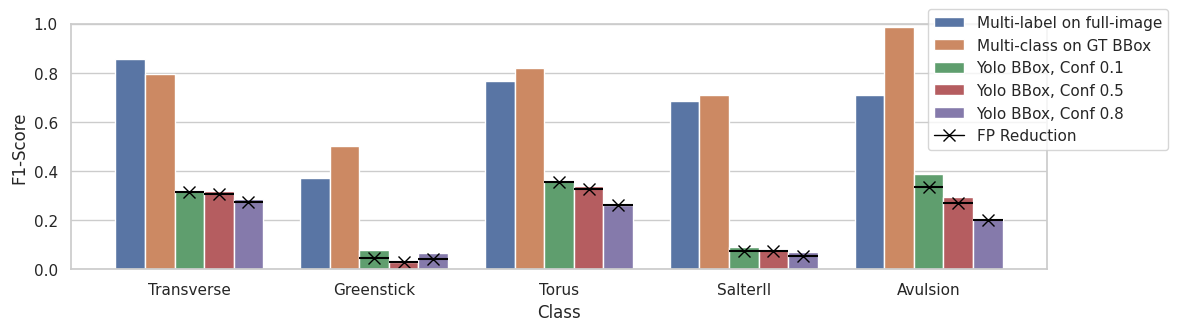

In [ ]:
path = "base_path_of_the_results_of_pretrained_model"
folders = ['baseline','gt','yolofn_confidence0.1','yolofn_confidence0.5','yolofn_confidence0.8'] # which models should be shown in plot
classes = ["Transverse","Greenstick","Torus","SalterII","Avulsion"] #Classes which should be shown in plot


records = []
fp_records = []

for folder in folders: # Run over all folders which should be visualized in one bar group
    f1_scores = read_class_f1(folder, path)
    for cls in classes:
        records.append({"Class": cls, "Model": folder, "F1": f1_scores[cls]})
    
    if folder.startswith("yolofn"):
        fp_folder = folder.replace("yolofn","yolofpfn")
        fp_scores = read_class_f1(fp_folder, path)
        for cls in classes:
            fp_records.append({"Class": cls, "Model": folder, "F1_FP": fp_scores[cls]})

df = pd.DataFrame(records)
df_fp = pd.DataFrame(fp_records)



df["ModelLabel"] = df["Model"].apply(format_label)

# FP-Reduction Dummy DataFrame
df_fp["ModelLabel"] = df_fp["Model"].apply(format_label)

# create plot
plt.figure(figsize=(12,3.5))
sns.set(style="whitegrid")

# barplots for the F1-Scores
n_colors = len(df["ModelLabel"].unique())
palette = sns.cubehelix_palette(start=0.25, rot=-0.25, n_colors=n_colors, dark=0.25, light=0.85)
ax = sns.barplot(x="Class", y="F1", hue="ModelLabel", data=df)

# FP-Reduction values as x and an additional line
for i, row in df_fp.iterrows():
    cls_idx = classes.index(row["Class"])
    model_idx = folders.index(row["Model"])
    n_models = len(folders)
    total_width = 0.8
    width = total_width / n_models
    x_pos = cls_idx - total_width/2 + width/2 + model_idx*width
    plt.plot(x_pos, row["F1_FP"], marker='x', color='black', markersize=8)

    ax.hlines(
        y=row["F1_FP"],
        xmin=x_pos - width/2,
        xmax=x_pos + width/2,
        colors="black",
        linestyles="-",
        linewidth=1.5
    )

# adapt legend for FP-Reduction
from matplotlib.lines import Line2D
custom_legend = Line2D([0], [0], marker='x',color='black',linestyle='-', markersize=8,linewidth=1.0, label='FP Reduction')


handles, labels = ax.get_legend_handles_labels()
# add custom legend to existing legend
handles.append(custom_legend)
labels.append(custom_legend.get_label())

ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.87, 1.09))

plt.ylim(0,1)
plt.ylabel("F1-Score")
plt.tight_layout()
plt.show()
